# **Tarea: Identificación de normalidad en el dataset regional.**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha de entrega** | Sábado 30 de mayo 2026 |

---



# **Dataset cargado**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Conexión al Spreadsheet
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'

try:
    df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
    df = df.dropna(how='all').reset_index(drop=True)
    print("¡Conexión exitosa a la hoja de Provincias!")

    # Verificando si la columna existe en el dataframe
    if 'tc_loss_ha_2024' in df.columns:
        print("La columna 'tc_loss_ha_2024' se encontró correctamente.")
    else:
        print("Alerta: No se encontró la columna exacta")

    display(df.head(15))

except Exception as e:
    print(f"Error: {e}")

¡Conexión exitosa a la hoja de Provincias!
La columna 'tc_loss_ha_2024' se encontró correctamente.


,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,...,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Ecuador,Azuay,0,816926,816926,816926,5887,1859,340,342,...,370,606,457,289,347,272,189,322,291,385
1,Ecuador,Azuay,10,816926,428633,484716,5887,1804,337,331,...,351,557,416,269,304,249,152,258,202,285
2,Ecuador,Azuay,15,816926,409481,472186,5887,1801,335,329,...,347,548,409,265,299,244,149,248,192,272
3,Ecuador,Azuay,20,816926,398952,464049,5887,1788,334,328,...,344,545,405,263,297,243,148,246,188,267
4,Ecuador,Azuay,25,816926,391864,450921,5887,1781,334,327,...,343,541,403,261,296,242,145,244,186,263
5,Ecuador,Azuay,30,816926,383423,435249,5887,1776,333,324,...,341,537,400,259,294,241,143,240,183,259
6,Ecuador,Azuay,50,816926,316850,328208,5887,1686,324,300,...,320,495,368,242,275,218,130,213,155,219
7,Ecuador,Azuay,75,816926,208116,237227,5887,1497,296,256,...,270,377,275,194,192,167,90,146,92,148
8,Ecuador,Bolivar,0,389964,389964,389964,4089,337,371,86,...,163,248,171,327,335,140,79,169,306,268
9,Ecuador,Bolivar,10,389964,253342,261961,4089,332,369,85,...,68,136,98,232,216,80,35,108,187,186


# **Paso 1: Exploración Gráfica (Visualización)**

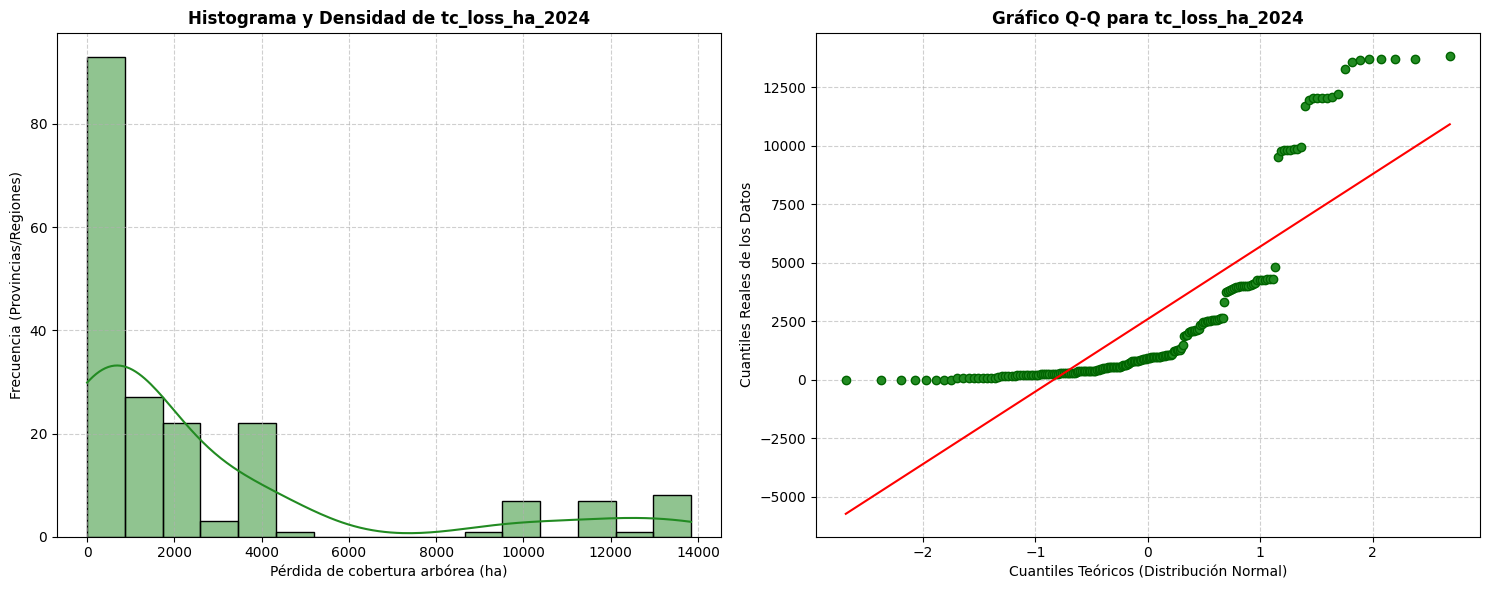

In [ ]:
# Configuración de la variable seleccionada
variable_clave = 'tc_loss_ha_2024'

# Filtrado para eliminar nulos o valores vacíos que afecten los cálculos
datos_analisis = df[variable_clave].dropna()

# Crear la figura para los dos gráficos en paralelo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histograma de Frecuencias con curva de densidad estimada (KDE)
sns.histplot(datos_analisis, kde=True, color='forestgreen', ax=axes[0])
axes[0].set_title(f'Histograma y Densidad de {variable_clave}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pérdida de cobertura arbórea (ha)')
axes[0].set_ylabel('Frecuencia (Provincias/Regiones)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Gráfico Q-Q (Quantile-Quantile Plot)
stats.probplot(datos_analisis, dist="norm", plot=axes[1])
# Personalización de colores
axes[1].get_lines()[0].set_markerfacecolor('forestgreen')
axes[1].get_lines()[0].set_markeredgecolor('darkgreen')
axes[1].get_lines()[1].set_color('red') # Línea de tendencia teórica
axes[1].set_title(f'Gráfico Q-Q para {variable_clave}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos (Distribución Normal)')
axes[1].set_ylabel('Cuantiles Reales de los Datos')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Paso 2: Análisis Analítico (Asimetría y Curtosis)**

In [ ]:
# Cálculo matemático de los coeficientes estadísticos
asimetria = datos_analisis.skew()
curtosis = datos_analisis.kurtosis() # Calcula curtosis en exceso (0 significa perfectamente mesocúrtica)

print("====================================================")
print("        ANÁLISIS ANALÍTICO DE NORMALIDAD (2024)     ")
print("====================================================")
print(f"Variable analizada: {variable_clave}\n")
print(f"• Coeficiente de Asimetría (Skewness): {asimetria:.4f}")
print(f"• Curtosis (En exceso): {curtosis:.4f}")
print("----------------------------------------------------")

# Interpretación automática del Sesgo (Asimetría)
if abs(asimetria) < 0.5:
    print("Interpretación Asimetría: Los datos son bastante simétricos (cercanos a 0).")
elif asimetria >= 0.5 and asimetria < 1:
    print("Interpretación Asimetría: Sesgo positivo moderado. Datos inclinados a la izquierda (cola a la derecha).")
elif asimetria >= 1:
    print("Interpretación Asimetría: Sesgo positivo severo. Gran concentración de valores bajos y una cola muy larga a la derecha.")
elif asimetria <= -0.5 and asimetria > -1:
    print("Interpretación Asimetría: Sesgo negativo moderado. Datos inclinados a la derecha (cola a la izquierda).")
else:
    print("Interpretación Asimetría: Sesgo negativo severo. Datos concentrados en valores altos y cola larga a la izquierda.")

# Interpretación automática del apuntamiento (Curtosis)
if abs(curtosis) < 0.5:
    print("Interpretación Curtosis: Distribución Mesocúrtica (curva similar a la normal estándar).")
elif curtosis >= 0.5:
    print("Interpretación Curtosis: Distribución Leptocúrtica (muy apuntada en el centro, con colas pesadas llenas de valores atípicos).")
else:
    print("Interpretación Curtosis: Distribución Platicúrtica (aplanada, con baja concentración en la media).")
print("====================================================")

        ANÁLISIS ANALÍTICO DE NORMALIDAD (2024)     
Variable analizada: tc_loss_ha_2024

• Coeficiente de Asimetría (Skewness): 1.9317
• Curtosis (En exceso): 2.5564
----------------------------------------------------
Interpretación Asimetría: Sesgo positivo severo. Gran concentración de valores bajos y una cola muy larga a la derecha.
Interpretación Curtosis: Distribución Leptocúrtica (muy apuntada en el centro, con colas pesadas llenas de valores atípicos).


# **Paso 3: Discusión Crítica (Hito del Proyecto)**

### Análisis de Normalidad para la variable `tc_loss_ha_2024`

* **RQ01. ¿Es matemáticamente correcto modelar esta variable de la región de Loja mediante una Distribución Normal?**

  **No, es matemáticamente incorrecto** modelar la variable `tc_loss_ha_2024` mediante una Distribución Normal. La evidencia recolectada a través de los componentes visuales y analíticos demuestra una desviación severa de los supuestos gaussianos:

  * **Evidencia Visual:** El *Histograma de Frecuencias* carece de la típica forma de campana simétrica; por el contrario, exhibe una altísima concentración de datos en valores bajos (menores a 2,000 ha) y una cola derecha sumamente alargada e interrumpida. Por su parte, el *Gráfico Q-Q (Quantile-Quantile)* ratifica este comportamiento, dado que los cuantiles reales de los datos (puntos verdes) no se alinean con la diagonal teórica roja. En su lugar, forman una pronunciada curva en "S", despegándose drásticamente en las colas debido a la presencia de valores extremos altos.
  * **Evidencia Analítica:** Los indicadores matemáticos respaldan la conclusión visual. El **Coeficiente de Asimetría (Skewness) de 1.9317** (significativamente mayor que 0) confirma un *sesgo positivo severo*, indicando que la distribución se inclina fuertemente a la izquierda. Asimismo, la **Curtosis en exceso de 2.5564** define una distribución de tipo *Leptocúrtica*, lo que matemáticamente se traduce en un apuntamiento elevado en el centro y colas pesadas pobladas por valores atípicos.

  Por lo tanto, aplicar un modelo estadístico normal a los datos de pérdida de cobertura arbórea de las subregiones (incluyendo el contexto analítico de Loja) distorsionaría la realidad del fenómeno.

---

* **RQ02. ¿Cómo afectaría la presencia de valores atípicos a las futuras pruebas de hipótesis de la Unidad 2?**

  La presencia de valores atípicos severos (regiones que registran pérdidas extremas cercanas a las 14,000 hectáreas en contraste con la mayoría que pierde menos de 2,000) tiene un impacto crítico y perjudicial en los métodos estadísticos paramétricos clásicos (como las pruebas *t de Student*, *ANOVA* o regresiones lineales) que se estudiarán en la Unidad 2:

  1. **Distorsión de Métricas Sensibles:** Valores atípicos tan marcados desplazan artificialmente la media muestral y aumentan desproporcionadamente la varianza y la desviación estándar, dejando de ser representantes legítimos de la tendencia central del dataset.
  2. **Inflación del Error y Pérdida de Potencia:** Al calcular los estadísticos de prueba, una varianza inflada reduce la sensibilidad de las pruebas. Esto incrementa la probabilidad de cometer **Errores de Tipo II** (no detectar una diferencia o efecto real cuando sí existe).
  3. **Violación de Supuestos Críticos:** Las pruebas paramétricas asumen de forma estricta la homocedasticidad y la normalidad de los residuos. Al forzar estos datos atípicos en dichas pruebas, se obtendrán *valores P (p-values)* poco confiables, conduciendo a conclusiones científicas erróneas o falsos positivos.

  **Conclusión de Ingeniería:** Para mitigar este problema en las próximas fases del proyecto, será imperativo aplicar transformaciones matemáticas a la variable (como una transformación logarítmica o raíz cuadrada) para estabilizar la varianza, o bien, recurrir directamente al uso de **estadística no paramétrica** (como la prueba de *Wilcoxon* o *Kruskal-Wallis*), las cuales trabajan con rangos y son robustas ante la presencia de valores atípicos.